**背景与动机**

强化学习用于语言模型微调（RLHF）的核心挑战是：如何在高维、离散的输出空间中稳定地估计状态价值。PPO 通过引入独立的 **Critic 网络**来解决这个问题，但对于参数量达百亿的 LLM，这意味着需要同时维护两个等规模的模型。GRPO（Group Relative Policy Optimization）由 DeepSeek 在 2024 年提出，其核心思想是：**通过组内采样的统计量代替 Critic，从而规避价值网络**。

**核心原理：群组相对优势**

对于每个问题 $q$，从当前旧策略 $\pi_{\theta_{old}}$ 中采样 $G$ 条输出（一个群组）：

$$\{o_1, o_2, \ldots, o_G\} \sim \pi_{\theta_{old}}(\cdot \mid q)$$

对每条输出送入奖励模型，得到标量奖励 $\{r_1, r_2, \ldots, r_G\}$，然后在**组内做标准化**，得到第 $i$ 条输出的优势估计：

$$\hat{A}_i = \frac{r_i - \mu_r}{\sigma_r + \epsilon}, \quad \mu_r = \frac{1}{G}\sum_{j=1}^G r_j,\quad \sigma_r = \sqrt{\frac{1}{G}\sum_{j=1}^G (r_j - \mu_r)^2}$$

这替代了 PPO 中需要 Critic 估计的 $V(s_t)$ 基线。$\hat{A}_i > 0$ 表示该输出优于组均值，$\hat{A}_i < 0$ 则相反。

**Token 级别的优势分配**：GRPO 使用 outcome-level 奖励（整条输出得一个分数），因此输出 $o_i$ 中**每个 token 都被赋予相同的优势值** $\hat{A}_i$：

$$\hat{A}_{i,t} = \hat{A}_i, \quad \forall t \in \{1, \ldots, |o_i|\}$$

这与 process-level reward 不同（后者对每步中间推理过程单独打分）。

**GRPO 目标函数与 Clip 机制**

GRPO 的训练目标为（最大化）：

$$\mathcal{L}(\theta) = \frac{1}{G} \sum_{i=1}^{G} \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \left[ \min\!\left( r_{i,t}(\theta)\,\hat{A}_i,\; \text{clip}\!\left(r_{i,t}(\theta), 1-\varepsilon, 1+\varepsilon\right)\hat{A}_i \right) - \beta\, D_\text{KL}\!\left[\pi_\theta \,\|\, \pi_\text{ref}\right] \right]$$

其中概率比（importance sampling ratio）为：

$$r_{i,t}(\theta) = \frac{\pi_\theta(o_{i,t} \mid q, o_{i,<t})}{\pi_{\theta_{old}}(o_{i,t} \mid q, o_{i,<t})}$$

KL 散度项使用一个无偏估计（Schulman 近似）以节省前向计算：

$$D_\text{KL}[\pi_\theta \| \pi_\text{ref}] \approx \frac{\pi_\text{ref}(o_{i,t} \mid \cdot)}{\pi_\theta(o_{i,t} \mid \cdot)} - \log \frac{\pi_\text{ref}(o_{i,t} \mid \cdot)}{\pi_\theta(o_{i,t} \mid \cdot)} - 1$$

**Clip 的作用**：当概率比 $r_{i,t}(\theta)$ 超出 $[1-\varepsilon, 1+\varepsilon]$ 时，梯度被截断为零，从而阻止策略在单次更新中偏离旧策略过远。其数学等价于：对好的动作（$\hat{A}>0$），不允许通过无限制地提升概率获取虚假收益；对坏的动作（$\hat{A}<0$），不允许无限制地惩罚。

**去掉 Clip 的后果**：梯度会正比于 $r_{i,t}$ 本身，当策略偶然在某条 token 上产生大的概率偏移时，会出现极端梯度，导致：训练振荡、策略崩溃（Policy Collapse）、奖励 hacking（模型找到使概率比爆炸的捷径而非真正提升质量）。

**大模型训练流程训练流程五步**：

- Rollout（旧策略推理采样 $G$ 条输出，`no_grad`，可多 GPU 并行）
- Scoring（奖励模型批量打分，也是 `no_grad`）
- Advantage（每个 batch 内组内标准化，CPU 操作）
- Loss 计算（前向传播，计算 clip 目标 + KL）
- 反向传播（只有 Policy 参数有梯度），每隔若干步将 $\theta$ 同步给 $\theta_{old}$

**显存分析**

GRPO 节省了 Critic 的 $4\Phi$（参数 + Adam 状态），等效于节省了约 $4 \times \text{model\_size}$ 的显存。

对 7B 模型（bf16 精度下约 14 GB），可节省 **~56 GB**，这在工程上意义重大。

**GRPO 相比 PPO 的核心优势**

PPO 的 Critic 是对 $V^\pi(s)$ 的函数逼近，其估计误差会污染优势 $\hat{A}$（高方差或偏差）。GRPO 的组内相对基线在数学期望上是无偏的：若 $G$ 足够大，$\mu_r \approx \mathbb{E}_{\pi_{old}}[r]$，即精确的 MC 基线。代价是对 $G$ 的敏感性：$G$ 太小时方差大，太大时计算代价高（通常 $G \in [4, 16]$）。

In [1]:
import torch
import torch.nn.functional as F
import math

inputs = {
    "prompt_ids": torch.randint(0, 10, (2, 10)),
    "prompt_mask": torch.ones(2, 10),
    "completion_ids": torch.randint(0, 8, (2, 8)),
    "completion_mask": torch.ones(2, 8)
}

prompt_ids, prompt_mask = inputs["prompt_ids"], inputs["prompt_mask"]
completion_ids, completion_mask = inputs["completion_ids"], inputs["completion_mask"]

如下即得到一次前向的 tokens 结果，也是 RL 范式上的 discrete action sequence，也是目标函数的输入。

In [2]:
input_ids = torch.cat([prompt_ids, completion_ids], dim=1)
mask = torch.cat([prompt_mask, completion_mask], dim=1)

input_ids, mask

(tensor([[1, 1, 4, 9, 6, 5, 8, 9, 9, 0, 7, 7, 4, 2, 4, 0, 5, 2],
         [7, 1, 9, 5, 4, 8, 2, 0, 1, 7, 2, 4, 5, 3, 4, 1, 2, 5]]),
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]))

基于 LSTM 的简易的语言模型和奖励模型。

In [3]:
class SimpleLanguageModel(torch.nn.Module):
    def __init__(self, vocab_size=10, hidden_dim=64):
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, 32)
        self.lstm = torch.nn.LSTM(32, hidden_dim, batch_first=True)
        self.lm_head = torch.nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embeddings)
        logits = self.lm_head(lstm_out)
        return logits

class RewardModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = torch.nn.Embedding(10, 32)
        self.lstm = torch.nn.LSTM(32, hidden_size=64, num_layers=2, batch_first=True)
        self.head = torch.nn.Linear(64, 1)

    def forward(self, prompt_ids, completion_ids):
        full_ids = torch.cat([prompt_ids, completion_ids], dim=1)
        embeddings = self.embedding(full_ids)
        lstm_out, _ = self.lstm(embeddings)
        final_hidden = lstm_out[:, -1, :]
        reward = self.head(final_hidden).squeeze(-1)
        return reward

policy_model = SimpleLanguageModel()
old_policy_model = SimpleLanguageModel()
reward_model = RewardModel()

从 PPO 到 GRPO，再到 GSPO 的目标函数公式实现。重点在于统计 token 和 sequence 上的优势，可以是整体共享的优势值，基于 GAE 计算（PPO）；也可以是按 sequence reward bias 不同计算的不同 sequence 的优势（GRPO）；也可以是按重要性比例进行代数、几何平均都是可以的，类似动量。

$$\mathcal{J}_{\mathrm{PPO}}(\theta)=\mathbb{E}_{x \sim \mathcal{D}, y \sim \pi_{\theta_{\text {old }}}(\cdot \mid x)}\left[\frac{1}{|y|} \sum_{t=1}^{|y|} \min \left(w_{t}(\theta) \widehat{A}_{t}, \operatorname{clip}\left(w_{t}(\theta), 1-\varepsilon, 1+\varepsilon\right) \widehat{A}_{t}\right)\right]$$

$$w_{t}(\theta)=\frac{\pi_{\theta}\left(y_{t} \mid x, y_{<t}\right)}{\pi_{\theta_{\text {old }}}\left(y_{t} \mid x, y_{<t}\right)}$$


In [4]:
import torch
import torch.nn.functional as F

eps = 0.2
log_probs = F.log_softmax(torch.randn(2, 8), dim=1)
old_log_probs = F.log_softmax(torch.randn(2, 8), dim=1)
advantages = torch.randn(2, 8)

ratio = (log_probs - old_log_probs).exp()
surr1 = ratio * advantages
surr2 = torch.clamp(ratio, 1 - eps, 1 + eps) * advantages

-torch.min(surr1, surr2).mean(dim=0)

tensor([ 1.1503,  0.6640,  4.8818, -0.1186,  1.1447,  0.2605,  0.2356,  0.7689])

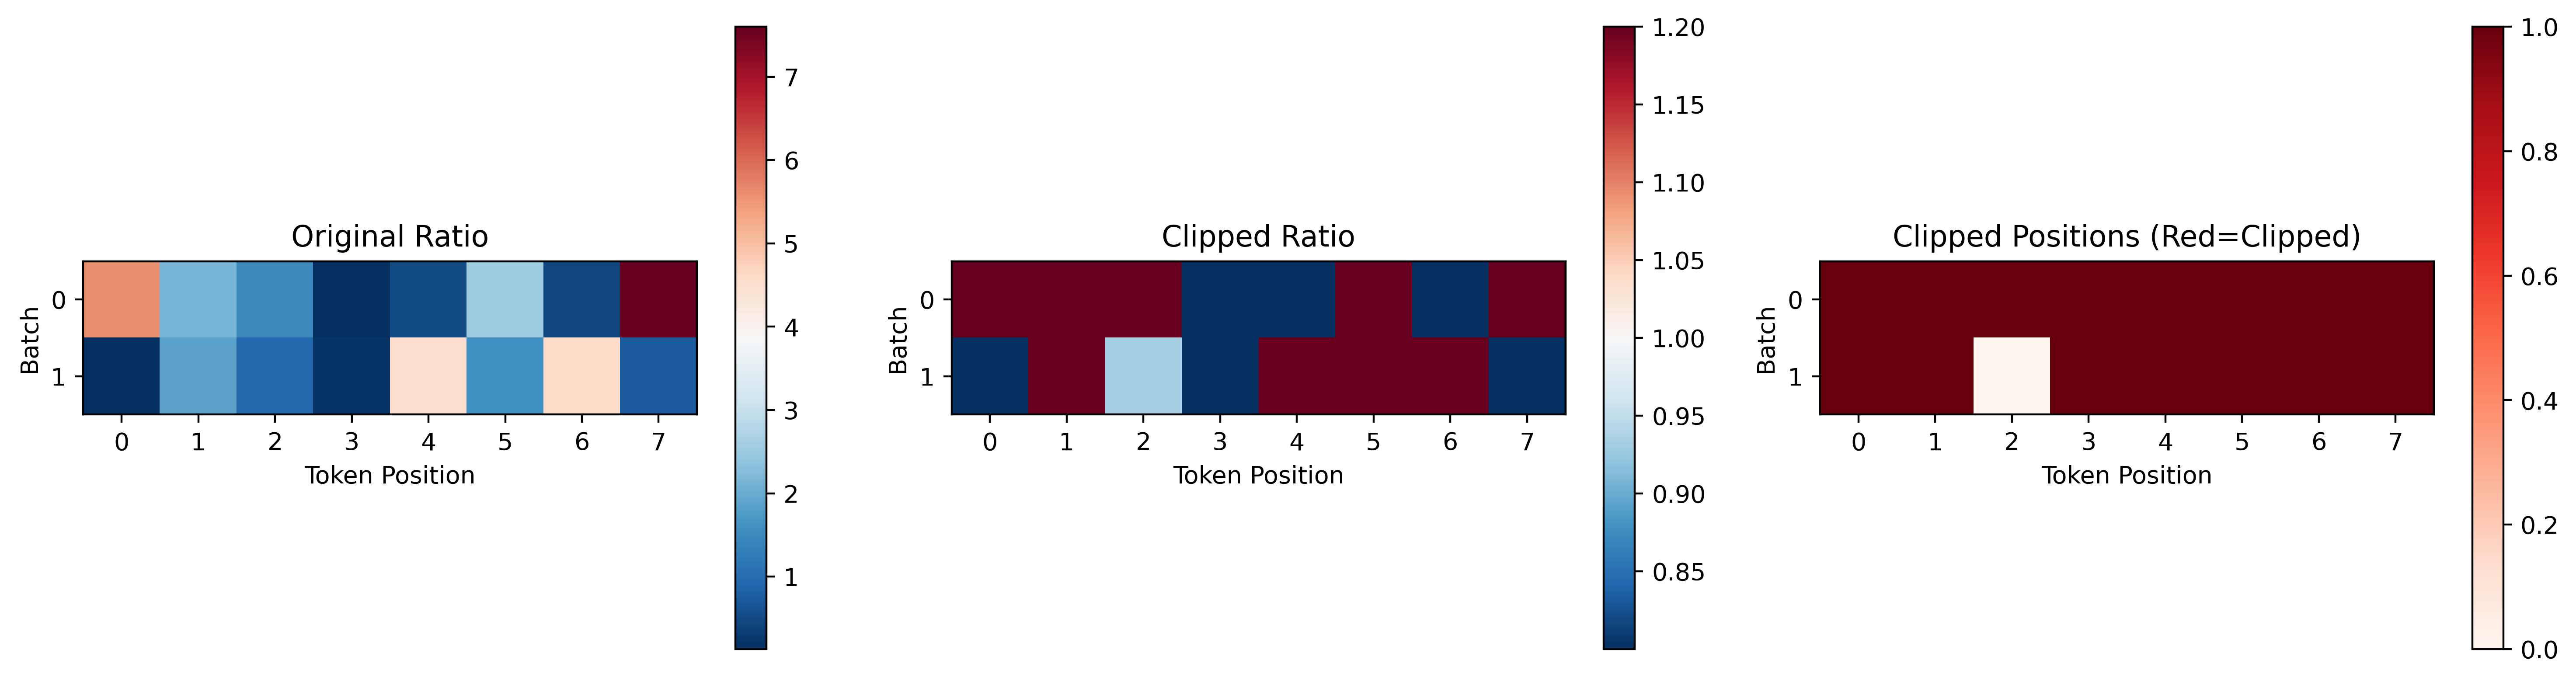

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize ratio and clipped ratio
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Original ratio
ratio_np = ratio.detach().numpy()
im1 = ax1.imshow(ratio_np, cmap='RdBu_r', aspect='equal')
ax1.set_title('Original Ratio')
ax1.set_xlabel('Token Position')
ax1.set_ylabel('Batch')
plt.colorbar(im1, ax=ax1)

# Clipped ratio
clipped_ratio = torch.clamp(ratio, 1 - eps, 1 + eps)
clipped_ratio_np = clipped_ratio.detach().numpy()
im2 = ax2.imshow(clipped_ratio_np, cmap='RdBu_r', aspect='equal')
ax2.set_title('Clipped Ratio')
ax2.set_xlabel('Token Position')
ax2.set_ylabel('Batch')
plt.colorbar(im2, ax=ax2)

# Show clipped positions
clipped_mask = (ratio != clipped_ratio).float().detach().numpy()
im3 = ax3.imshow(clipped_mask, cmap='Reds', aspect='equal')
ax3.set_title('Clipped Positions (Red=Clipped)')
ax3.set_xlabel('Token Position')
ax3.set_ylabel('Batch')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.gcf().set_dpi(400)
plt.show()

In [11]:
print(f"Clipping range: [{1-eps:.1f}, {1+eps:.1f}]")
print("Original ratio:")
print(ratio)
print("\nClipped ratio:")
print(clipped_ratio)

Clipping range: [0.8, 1.2]
Original ratio:
tensor([[5.6070, 2.1411, 1.4494, 0.1305, 0.5283, 2.5285, 0.4506, 7.6014],
        [0.1332, 1.8733, 0.9329, 0.2059, 4.5073, 1.5840, 4.5650, 0.7462]])

Clipped ratio:
tensor([[1.2000, 1.2000, 1.2000, 0.8000, 0.8000, 1.2000, 0.8000, 1.2000],
        [0.8000, 1.2000, 0.9329, 0.8000, 1.2000, 1.2000, 1.2000, 0.8000]])


$$\mathcal{J}_{\mathrm{GRPO}}(\theta)=\mathbb{E}_{x \sim \mathcal{D},\left\{y_{i}\right\}_{i=1}^{G} \sim \pi_{\theta_{\text {old }}}(\cdot \mid x)}\left[\frac{1}{G} \sum_{i=1}^{G} \frac{1}{\left|y_{i}\right|} \sum_{t=1}^{\left|y_{i}\right|} \min \left(w_{i, t}(\theta) \widehat{A}_{i, t}, \operatorname{clip}\left(w_{i, t}(\theta), 1-\varepsilon, 1+\varepsilon\right) \widehat{A}_{i, t}\right)\right]$$
$$w_{i, t}(\theta)=\frac{\pi_{\theta}\left(y_{i, t} \mid x, y_{i,<t}\right)}{\pi_{\theta_{\text {old }}}\left(y_{i, t} \mid x, y_{i,<t}\right)}, \quad \widehat{A}_{i, t}=\widehat{A}_{i}=\frac{r\left(x, y_{i}\right)-\operatorname{mean}\left(\left\{r\left(x, y_{i}\right)\right\}_{i=1}^{G}\right)}{\operatorname{std}\left(\left\{r\left(x, y_{i}\right)\right\}_{i=1}^{G}\right)}$$

In [15]:
import torch
import torch.nn.functional as F

eps = 0.2
log_probs = F.log_softmax(torch.randn(2, 8), dim=1)
old_log_probs = F.log_softmax(torch.randn(2, 8), dim=1)

rewards = torch.randn(2, 1)
rewards = (rewards - rewards.mean(dim=0)) / (rewards.std(dim=0) + 1e-6)
advantages = rewards.expand(size=(2, 8))

ratio = (log_probs - old_log_probs).exp()
surr1 = ratio * advantages
surr2 = torch.clamp(ratio, 1 - eps, 1 + eps) * advantages

-torch.min(surr1, surr2).mean()

tensor(0.3446)